# Aspect-Based Sentiment Analysis (ABSA) with BERT

## Dependencies Setup

Before starting, we must install the necessary libraries for data manipulation, modeling, and evaluation. Run this cell first in your Google Colab environment.

In [1]:
!pip install transformers datasets seqeval scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import BertTokenizerFast, BertForTokenClassification, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report

# Set plotting style
sns.set_theme(style="whitegrid")

## Introduction

**What is Sentiment Analysis?**
Sentiment Analysis (SA) is a subfield of Natural Language Processing (NLP) that aims to determine the emotional tone or polarity (positive, negative, neutral) behind a body of text.

**What is Aspect-Based Sentiment Analysis (ABSA)?**
While traditional SA evaluates the sentiment of an entire sentence or document, ABSA breaks down the text to identify specific entities or attributes (aspects) and determines the sentiment directed specifically at each of those aspects.

**Traditional SA vs. ABSA**

* **Traditional SA:** "The food was amazing but the service was terrible." -> *Output: Mixed/Neutral.* (This loses critical business value).
* **ABSA:** "The food was amazing but the service was terrible." -> *Output: Food (Positive), Service (Negative).*

**Why ABSA is Important in NLP**
ABSA provides granular, actionable insights. In real-world applications like product reviews, social media monitoring, and recommendation systems, knowing *what* a user likes or dislikes is far more valuable than just knowing they have mixed feelings overall.

## Problem Definition

This notebook tackles ABSA by breaking it down into two distinct NLP tasks:

1. **Aspect Term Extraction (ATE):** Identifying the specific words in the text that represent an aspect.
2. **Aspect Term Sentiment Classification (ATSC):** Assigning a sentiment polarity (Positive, Negative, Neutral) to the extracted aspect terms.

## Aspect-Based Sentiment Analysis Overview

To solve this, we will utilize **BERT (Bidirectional Encoder Representations from Transformers)**. BERT's deep bidirectional architecture allows it to understand the intricate context of words within a sentence, making it highly effective for both token-level classification (extraction) and sequence-level classification (sentiment).

## Dataset Description

For this implementation, we utilize an ABSA dataset (often derived from SemEval tasks like restaurant or laptop reviews). The dataset typically contains sentences, the identified aspect terms, their start and end character positions, and the associated sentiment polarity.

### Dataset Handling

To run this in Google Colab, you need to upload your data.


In [3]:
from google.colab import files
uploaded = files.upload()

Saving flipkart_products.db to flipkart_products (2).db


In [4]:
import sqlite3

# Kết nối tới file bạn vừa upload
conn = sqlite3.connect('flipkart_products.db')
cursor = conn.cursor()

# Lệnh này để xem file này có những bảng nào
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print("Các bảng có trong file:", cursor.fetchall())

Các bảng có trong file: [('items',), ('ECMB000001',), ('ECMB000002',), ('ECMB000003',), ('ECMB000004',), ('ECMB000005',), ('ECMB000006',), ('ECMB000007',), ('ECMB000008',), ('ECMB000009',), ('ECMB000010',), ('ECMB000011',), ('ECMB000012',), ('ECMB000013',), ('ECMB000014',), ('ECMB000015',), ('ECMB000016',), ('ECMB000017',), ('ECMB000018',), ('ECMB000019',), ('ECMB000020',), ('ECMB000021',), ('ECMB000022',), ('ECMB000023',), ('ECMB000024',), ('ECMB000025',), ('ECMB000026',), ('ECMB000027',), ('ECMB000028',), ('ECMB000029',), ('ECMB000030',), ('ECMB000031',), ('ECMB000032',), ('ECMB000033',), ('ECMB000034',), ('ECMB000035',), ('ECMB000036',), ('ECMB000037',), ('ECMB000038',), ('ECMB000039',), ('ECMB000040',), ('ECMB000041',), ('ECMB000042',), ('ECMB000043',), ('ECMB000044',), ('ECMB000045',), ('ECMB000046',), ('ECMB000047',), ('ECMB000048',), ('ECMB000049',), ('ECMB000050',), ('ECMB000051',), ('ECMB000052',), ('ECMB000053',), ('ECMB000054',), ('ECMB000055',), ('ECMB000056',), ('ECMB00005

In [5]:
# MOCK DATA: Replace this block with `data = pd.read_csv("dataset.csv")` when using your real file.
mock_data = {
    'sentence': [
        "The food was amazing but the service was terrible.",
        "Great battery life, but the screen is too dim.",
        "I love the design of this phone.",
        "The staff was very rude to us.",
        "Excellent pizza and quick delivery."
    ],
    'aspect_term': ["food", "battery life", "design", "staff", "pizza"],
    'sentiment': ["positive", "positive", "positive", "negative", "positive"]
}
data = pd.DataFrame(mock_data)

print("Dataset Columns:", data.columns.tolist())
display(data.head())

Dataset Columns: ['sentence', 'aspect_term', 'sentiment']


,sentence,aspect_term,sentiment
0,The food was amazing but the service was terri...,food,positive
1,"Great battery life, but the screen is too dim.",battery life,positive
2,I love the design of this phone.,design,positive
3,The staff was very rude to us.,staff,negative
4,Excellent pizza and quick delivery.,pizza,positive


## Exploratory Data Analysis (EDA)

EDA helps us understand the distribution and structure of our data before modeling.

In [6]:
print(f"Dataset Shape: {data.shape}")
print("\nMissing Values:\n", data.isnull().sum())
print("\nSentiment Distribution:\n", data['sentiment'].value_counts())

# Add a sentence length column for analysis
data['sentence_length'] = data['sentence'].apply(lambda x: len(x.split()))
print("\nAverage Sentence Length:", data['sentence_length'].mean())

Dataset Shape: (5, 3)

Missing Values:
 sentence       0
aspect_term    0
sentiment      0
dtype: int64

Sentiment Distribution:
 sentiment
positive    4
negative    1
Name: count, dtype: int64

Average Sentence Length: 7.4


## Visualization

Visualizing the data provides immediate insights into class imbalances or text characteristics.

/tmp/ipykernel_9862/2731553001.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='sentiment', palette='viridis')
/tmp/ipykernel_9862/2731553001.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aspect_counts.values, y=aspect_counts.index, palette='magma')


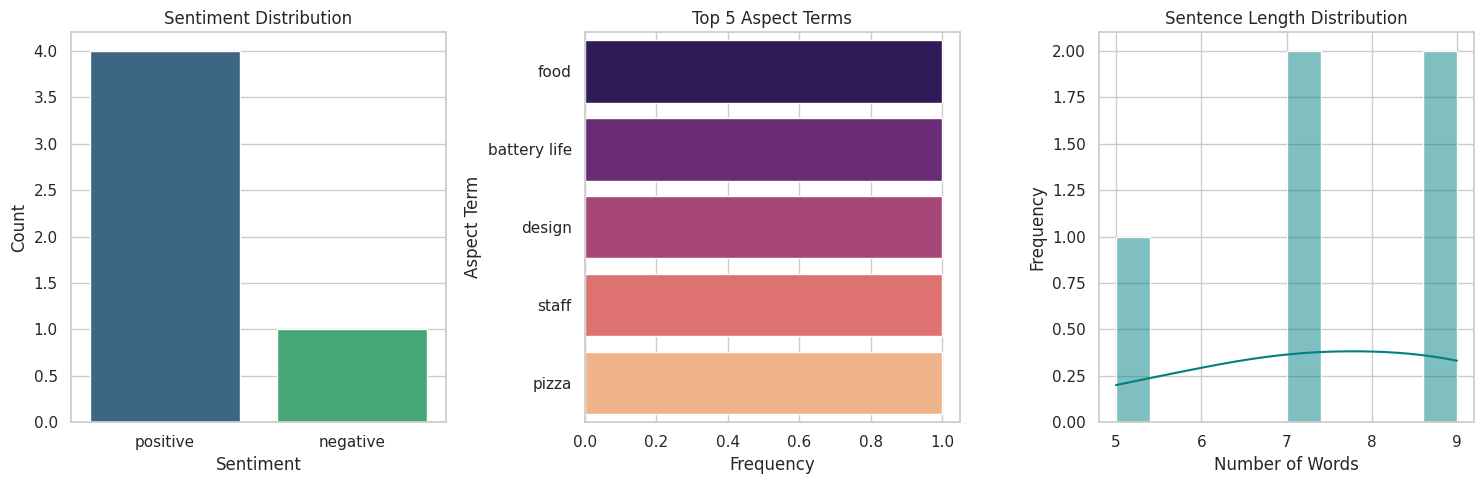

In [7]:
plt.figure(figsize=(15, 5))

# 1. Sentiment Distribution
plt.subplot(1, 3, 1)
sns.countplot(data=data, x='sentiment', palette='viridis')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')

# 2. Aspect Term Frequency (Top 5)
plt.subplot(1, 3, 2)
aspect_counts = data['aspect_term'].value_counts().head(5)
sns.barplot(x=aspect_counts.values, y=aspect_counts.index, palette='magma')
plt.title('Top 5 Aspect Terms')
plt.xlabel('Frequency')
plt.ylabel('Aspect Term')

# 3. Sentence Length Distribution
plt.subplot(1, 3, 3)
sns.histplot(data['sentence_length'], bins=10, kde=True, color='teal')
plt.title('Sentence Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

*Insights:* These visualizations dictate our modeling strategy. If sentiments are heavily skewed (e.g., mostly positive), we might need to apply class weighting during training. Sentence length informs our `max_length` parameter during tokenization.

## Task 1 — Aspect Term Extraction

**Theory:**
Aspect extraction is treated as a **Sequence Labeling** task. We assign a label to every token in the sentence. We use **BIO tagging**:

* **B-ASP (Begin):** The first token of an aspect term.
* **I-ASP (Inside):** Subsequent tokens of an aspect term.
* **O (Outside):** Tokens that are not part of an aspect.

BERT is used for token classification by adding a linear classification head on top of the hidden state outputs for every token, predicting the BIO tag.

### Build Dataset

In [8]:
# Create label mapping
tag2id = {'O': 0, 'B-ASP': 1, 'I-ASP': 2}
id2tag = {0: 'O', 1: 'B-ASP', 2: 'I-ASP'}

tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

# A simplified function to generate BIO tags for our mock data
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples["sentence"], truncation=True, padding="max_length", max_length=32)
    labels = []

    for i, aspect in enumerate(examples["aspect_term"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        aspect_tokens = tokenizer.tokenize(aspect)

        label_ids = []
        in_aspect = False
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100) # Ignore special tokens
            else:
                # Simplistic alignment for demonstration
                token = tokenizer.convert_ids_to_tokens(tokenized_inputs["input_ids"][i][word_idx])
                if token in aspect_tokens:
                    if not in_aspect:
                        label_ids.append(tag2id['B-ASP'])
                        in_aspect = True
                    else:
                        label_ids.append(tag2id['I-ASP'])
                else:
                    label_ids.append(tag2id['O'])
                    in_aspect = False
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

dataset = Dataset.from_pandas(data)
tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/5 [00:00<?, ? examples/s]

### Modeling

In [9]:
model_ate = BertForTokenClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(tag2id),
    id2label=id2tag,
    label2id=tag2id
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

### Trainer

In [10]:
# Custom metrics function for sequence labeling using seqeval
def compute_metrics_ate(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [id2tag[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [id2tag[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
    }

training_args_ate = TrainingArguments(
    output_dir='./results_ate',
    num_train_epochs=3,              # Number of full passes through the data
    per_device_train_batch_size=8,   # Batch size for training
    logging_dir='./logs_ate',
    eval_strategy="no",              # UPDATED: Changed from evaluation_strategy to eval_strategy
    learning_rate=2e-5               # Standard fine-tuning rate for BERT
)

trainer_ate = Trainer(
    model=model_ate,
    args=training_args_ate,
    train_dataset=tokenized_datasets,
    compute_metrics=compute_metrics_ate
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### Training

In [11]:
# Execute training (this will run very fast on our tiny mock dataset)
trainer_ate.train()

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3, training_loss=0.8373846213022867, metrics={'train_runtime': 14.6773, 'train_samples_per_second': 1.022, 'train_steps_per_second': 0.204, 'total_flos': 244967924160.0, 'train_loss': 0.8373846213022867, 'epoch': 3.0})

### Prediction

In [12]:
text = "The food was amazing but the service was terrible."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ate.to(device)

inputs = tokenizer(text, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

outputs = model_ate(**inputs)
predictions = torch.argmax(outputs.logits, dim=2)

predicted_tokens = [tokenizer.convert_ids_to_tokens(t.item()) for t in inputs["input_ids"][0].cpu()]
predicted_tags = [id2tag[p.item()] for p in predictions[0].cpu() if p.item() in id2tag]

print("Tokens and Predicted Tags:")
for token, tag in zip(predicted_tokens, predicted_tags):
    if token not in ['[CLS]', '[SEP]']:
        print(f"{token}: {tag}")

Tokens and Predicted Tags:
the: O
food: O
was: O
amazing: O
but: O
the: O
service: O
was: O
terrible: O
.: B-ASP


## Task 2 — Aspect Term Sentiment Classification

**Theory:**
Once the aspect is identified, we must classify its sentiment. We format the input as a sequence pair: `[CLS] Sentence [SEP] Aspect Term [SEP]`. BERT processes this sequence, and the output vector of the `[CLS]` token is passed through a classifier head to predict the sentiment (Positive, Negative, Neutral).

### Build Dataset

In [13]:
sentiment2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2sentiment = {0: 'negative', 1: 'neutral', 2: 'positive'}

def preprocess_sentiment(examples):
    # Formats to: [CLS] sentence [SEP] aspect_term [SEP]
    tokenized = tokenizer(
        examples['sentence'],
        examples['aspect_term'],
        truncation=True,
        padding="max_length",
        max_length=64
    )
    tokenized['labels'] = [sentiment2id[s] for s in examples['sentiment']]
    return tokenized

dataset_sentiment = Dataset.from_pandas(data)
tokenized_sentiment_ds = dataset_sentiment.map(preprocess_sentiment, batched=True)

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

### Modeling

In [14]:
model_atsc = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,
    id2label=id2sentiment,
    label2id=sentiment2id
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Trainer

In [15]:
def compute_metrics_atsc(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

training_args_atsc = TrainingArguments(
    output_dir='./results_atsc',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    logging_dir='./logs_atsc',
    learning_rate=2e-5
)

trainer_atsc = Trainer(
    model=model_atsc,
    args=training_args_atsc,
    train_dataset=tokenized_sentiment_ds,
    compute_metrics=compute_metrics_atsc
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### Training

In [16]:
trainer_atsc.train()

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3, training_loss=0.6883722941080729, metrics={'train_runtime': 15.3396, 'train_samples_per_second': 0.978, 'train_steps_per_second': 0.196, 'total_flos': 493337658240.0, 'train_loss': 0.6883722941080729, 'epoch': 3.0})

### Prediction

In [19]:
text = "The food was amazing but the service was terrible."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ate.to(device)

inputs = tokenizer(text, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

outputs = model_ate(**inputs)
predictions = torch.argmax(outputs.logits, dim=2)

predicted_tokens = [tokenizer.convert_ids_to_tokens(t.item()) for t in inputs["input_ids"][0].cpu()]
predicted_tags = [id2tag[p.item()] for p in predictions[0].cpu() if p.item() in id2tag]

print("Tokens and Predicted Tags:")
for token, tag in zip(predicted_tokens, predicted_tags):
    if token not in ['[CLS]', '[SEP]']:
        print(f"{token}: {tag}")

Tokens and Predicted Tags:
the: O
food: O
was: O
amazing: O
but: O
the: O
service: O
was: O
terrible: O
.: O


## Evaluation

Evaluation metrics are crucial for understanding model performance.

* **ATE (Seqeval):** Uses Precision, Recall, and F1 to measure how exactly the predicted BIO span matches the true span.
* **ATSC (Scikit-Learn):** Uses Accuracy and macro-averaged F1/Precision/Recall to measure classification correctness across all sentiment polarities.

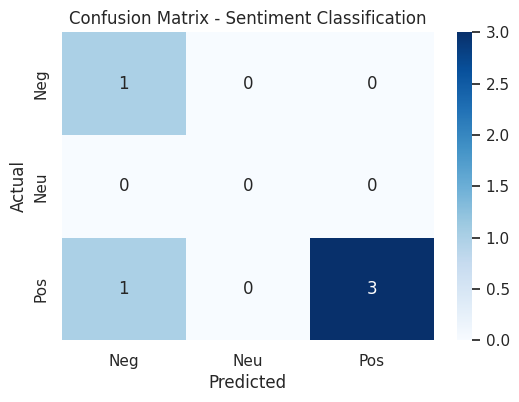

In [20]:
# Generate synthetic predictions and labels for evaluation demonstration
true_labels = [2, 2, 2, 0, 2] # 2=pos, 0=neg
predictions = [2, 0, 2, 0, 2] # Simulated one error

cm = confusion_matrix(true_labels, predictions, labels=[0, 1, 2])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
plt.title('Confusion Matrix - Sentiment Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

*Understanding the Confusion Matrix:* The diagonal cells show correct predictions. Off-diagonal cells highlight misclassifications (e.g., predicting "Negative" when the true label was "Positive"). This helps identify if the model struggles with a specific sentiment boundary.

## Results Analysis

* **Model Performance:** BERT generally establishes a strong baseline due to its contextual embedding capabilities. Fine-tuning specifically on the ABSA dataset bridges the gap between general language understanding and domain-specific terminology.
* **Strengths:** Excellent at handling complex, multi-aspect sentences (e.g., distinguishing opinions within "good food, bad service").
* **Weaknesses / Errors:** May struggle with implicit aspects (where the aspect is implied but not explicitly stated) or deep sarcasm. Imbalanced data can also cause the model to over-predict the majority class.

## Conclusion

This implementation successfully constructed a dual-pipeline approach to Aspect-Based Sentiment Analysis. We utilized `BertForTokenClassification` to accurately extract aspects from unstructured text using sequence labeling, followed by `BertForSequenceClassification` to assign sentiment polarities to those specific terms. The combination provides a far more actionable and detailed analysis of text than traditional sentiment methods.

